In [32]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl
import json

In [33]:
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/new_data_MZB.csv')
df_ont = pd.read_excel('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/20190412_MV_Bcellnumbers_ontogeny.xlsx', sheet_name='SPLEEN_Cell number')
df_ont_T1 = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/ontogeny_counts.csv')
# print(df_new.head(10))
print(df_ont)


                                    mouse  age.at.S1K  \
0          Samples_Spleen_002_d11_017.fcs          11   
1          Samples_Spleen_003_d11_018.fcs          11   
2          Samples_Spleen_004_d11_019.fcs          11   
3          Samples_Spleen_005_d11_020.fcs          11   
4          Samples_Spleen_006_d14_021.fcs          14   
..                                    ...         ...   
57       X20190201_Spleen_57d_006_016.fcs          57   
58      X20180907_TH283_Bcells_SP_002.fcs          71   
59      X20181023_MV60_Bcells_SPL_001.fcs         113   
60  X20181120_MV60_d26_SPLEEN_006_021.fcs         152   
61  X20181120_MV60_d26_SPLEEN_007_022.fcs         152   

    T1 (old gating used for FMs)  Transitional2            FM  \
0                   3.623153e+06   2.731288e+06  3.647747e+05   
1                   2.806500e+06   2.122800e+06  2.569500e+05   
2                   2.960302e+06   2.362542e+06  3.841860e+05   
3                   2.342291e+06   2.149343e+06  3.5486

In [37]:

# Change column name to match the other dataframe
df_new1 = df_new.rename(columns = {'Age at S1K':'age.at.S1K'})
df_ont1 = df_ont.rename(columns = {'Transitional2':'total_T2', 'MZ': 'total_MZ', 'FM': 'total_FM'})

# Select only the total_T2 and total_MZ columns
df_T2counts_Nfd = df_new1.filter(items=['age.at.S1K', 'total_T2', 'total_MZ'])
df_T2counts_ont = df_ont1.filter(items=['age.at.S1K', 'total_T2', 'total_MZ'])

df_FOcounts_Nfd = df_new1.filter(items=['age.at.S1K', 'total_FM', 'total_MZ'])
df_FOcounts_ont = df_ont1.filter(items=['age.at.S1K', 'total_FM', 'total_MZ'])

df_ont_T2_FO = df_ont1.filter(items=['age.at.S1K', 'total_T2', 'total_FM'])
print(df_ont_T2_FO.head(20)) 


# combine in one dataframe for T2 counts and FM counts 
total_T2counts = pd.concat([df_T2counts_Nfd, df_T2counts_ont])
total_T2counts = total_T2counts.sort_values(by='age.at.S1K')
print(total_T2counts.head(10))

total_FOcounts = pd.concat([df_FOcounts_Nfd, df_FOcounts_ont])
total_FOcounts = total_FOcounts.sort_values(by='age.at.S1K')
print(total_FOcounts.head(10))


#save the data to a csv file
df_ont_T2_FO.to_csv('/home/apoorva/Desktop/work/MZ_analysis/data/Ontogeny_T2_FO.csv', index=False)
# df_T1counts_Nfd.to_csv('/home/apoorva/Desktop/work/MZ_analysis/data/T1counts_Nfd.csv', index=False)
# df_T1counts_ont.to_csv('/home/apoorva/Desktop/work/MZ_analysis/data/T1counts_ont.csv', index=False)


# Creating a list to use as an input in Stan model

# data_T2 = {'numobs': len(total_T2counts['age.at.S1K']), 
#         'numsolve' : total_T2counts['age.at.S1K'].tolist(),
#         'numT2counts' : total_T2counts['total_T2'].tolist(),
#         'time_pred' : np.array(np.arange(10,731,1)).tolist(),
#         'num_pred' : len(np.array(np.arange(10,731,1)))
# }


# data_FO = {'numobs': len(total_FOcounts['age.at.S1K']), 
#         'numsolve' : total_FOcounts['age.at.S1K'].tolist(),
#         'numFOcounts' : total_FOcounts['total_FM'].tolist(),
#         'time_pred' : np.array(np.arange(10,731,1)).tolist(),
#         'num_pred' : len(np.array(np.arange(10,731,1)))
# }

# json_string = json.dumps(data_T2)

# file_path1 = '/home/apoorva/Desktop/work/MZ_analysis/data/New_data/data_T2fits.json'
# with open(file_path1, 'wb') as json_file:
#     json_file.write(json_string.encode())

# json_string1 = json.dumps(data_FO)
# file_path2 = '/home/apoorva/Desktop/work/MZ_analysis/data/New_data/data_FOfits.json'
# with open(file_path2, 'wb') as json_file:
#     json_file.write(json_string1.encode())

    age.at.S1K      total_T2      total_FM
0           11  2.731288e+06  3.647747e+05
1           11  2.122800e+06  2.569500e+05
2           11  2.362542e+06  3.841860e+05
3           11  2.149343e+06  3.548619e+05
4           14  6.346286e+06  1.073027e+06
5           14  7.715313e+06  7.060185e+05
6           14  6.660167e+06  7.507756e+05
7           14  7.901520e+06  9.489268e+05
8           14  7.312914e+06  9.275701e+05
9           18  5.939788e+06  3.043410e+06
10          18  7.324919e+06  2.676202e+06
11          18  9.577272e+06  3.395524e+06
12          18  7.151192e+06  3.091874e+06
13          19  7.772044e+06  1.156576e+06
14          19  2.177142e+06  3.811303e+05
15          20  1.537387e+07  2.901315e+06
16          20  1.176457e+07  2.131049e+06
17          20  1.204250e+07  2.658156e+06
18          20  9.662639e+06  3.421610e+06
19          20  6.783357e+06  1.425893e+06
   age.at.S1K      total_T2      total_MZ
2          11  2.362542e+06   18873.23894
3          11

In [ ]:
#Clean T1 data for ontogeny

# Change column name to match the other dataframe
df_ont1 = df_ont_T1.rename(columns = {'T1 AA4.1+_total':'total_T1_AA4.1+', 'MZ_total':'total_MZ'})

df_T1counts_ont = df_ont1.filter(items=['age.at.S1K', 'total_T1_AA4.1+', 'total_MZ'])
print(df_T1counts_ont.head(10))




   age.at.S1K  total_T1_AA4.1+       total_MZ
0          11     4.145272e+06   12058.666667
1          11     3.223400e+06    7450.000000
2          11     3.302817e+06   18873.238938
3          11     2.677656e+06   11941.171604
4          14     6.970682e+06  173580.615385
5          14     8.923469e+06   65914.813614
6          14     9.934749e+06   55375.823430
7          14     9.792409e+06  102645.316456
8          14     8.129739e+06  152588.316151
9          18     8.048254e+06  120475.287009


In [36]:
# data time points
data_time = total_T2counts['age.at.S1K'].values
data_time = data_time[4:]
# Create a dataframe with unique age at S1K values
dfunique = total_T2counts.drop_duplicates(subset='age.at.S1K', keep='first')
dfunique = dfunique.sort_values(by='age.at.S1K')
dfunique = dfunique.reset_index(drop=True)

# unique time points in data
solve_time = dfunique['age.at.S1K'].values
solve_time = solve_time[1:]
# solve_ageatbmt = dfunique['Age at BMT'].values

# create index map of data time to solve time for Nfd
time_index_map = np.zeros(len(data_time), dtype=int)
for i, t in enumerate(solve_time):
    time_index_map[data_time == t] = i+1

print(time_index_map)
#time sequence for predictions specific to agebins within the data
time_pred1_solve= np.array(np.arange(11.1, 732.1, 0.1))


NameError: name 'total_T2counts' is not defined

In [ ]:
# Create a dataframe with unique age at S1K values for ontogeny data
# data time points
data_time_ont = df_T2counts_ont['age.at.S1K'].values
data_time_ont = data_time_ont[4:]

# Create a dataframe with unique age at S1K values
df_unique_ont = df_T2counts_ont.drop_duplicates(subset='age.at.S1K', keep='first')
df_unique_ont = df_unique_ont.sort_values(by='age.at.S1K')
df_unique_ont = df_unique_ont.reset_index(drop=True)

# unique time points in data
solve_time_ont = df_unique_ont['age.at.S1K'].values
solve_time_ont = solve_time_ont[1:]
# solve_ageatbmt = dfunique['Age at BMT'].values

# create index map of data time to solve time for Nfd
time_index_map_ont = np.zeros(len(data_time_ont), dtype=int)
for i, t in enumerate(solve_time_ont):
    time_index_map_ont[data_time_ont == t] = i+1

print(len(time_index_map_ont))
print(solve_time_ont)
print(data_time_ont)
print(len(np.array(df_T2counts_ont['total_MZ'])))
#time sequence for predictions specific to agebins within the data
time_pred_solve= np.array(np.arange(11.1, 732.1, 0.1))

58
[ 14  18  19  20  22  23  24  25  26  27  28  29  31  33  36  39  43  53
  57  71 113 152]
[ 14  14  14  14  14  18  18  18  18  19  19  20  20  20  20  20  20  22
  22  22  22  23  23  23  23  24  24  24  24  24  24  25  25  26  26  26
  26  26  27  28  28  29  29  31  31  31  31  33  33  36  39  43  53  57
  71 113 152 152]
62


In [ ]:
data_mz_ontogenyT1={"numobs" : len(data_time_ont),  # Number of donor fraction observations
      "numsolve" : len(solve_time_ont),  # Number of unique time points in the data
      "data_time" : data_time_ont,
      "time_index_map" : time_index_map_ont,
      "solve_time" : solve_time_ont,
      "totalMZ" : np.array(df_T2counts_ont['total_MZ'][4:]),
      "time_pred1_solve" : time_pred_solve,
      "numpred" : len(time_pred1_solve)}

# Export data to JSON
def numpy_array_encoder(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()  # Convert numpy array to a list
    raise TypeError("Object of type {} is not JSON serializable".format(type(obj)))

# Serialize dictionary to JSON using custom encoder function
json_string = json.dumps(data_mz_ontogenyT1, default=numpy_array_encoder)

file_path= "/home/apoorva/Desktop/work/MZ_analysis/data/New_data/MZcounts_ontogeny_T2FO.json"
with open(file_path, "w") as json_file:  json_file.write(json_string)

print("Data saved to", file_path)

Data saved to /home/apoorva/Desktop/work/MZ_analysis/data/New_data/MZcounts_ontogeny_T2FO.json


/tmp/ipykernel_1795435/4152641060.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


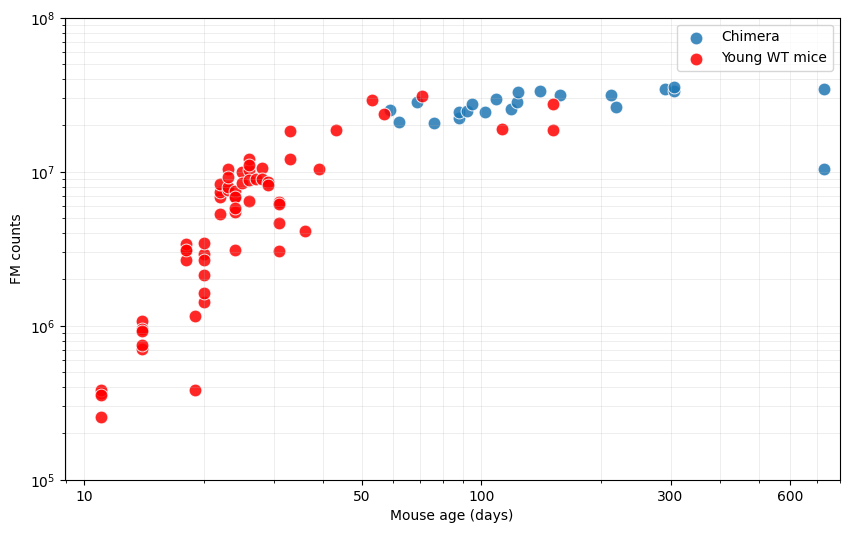

In [ ]:
# Plot FM counts

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_FM', alpha=0.85 ,s=85, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='FM', alpha=0.85, s=85, color = 'Red',label='Young WT mice', legend=False)
# plt.plot(np.arange(11, 800, 0.05), P(np.arange(11, 800, 0.05)))
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 1e8)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 50,  100, 300, 600], [10, 50, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('FM counts')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()